In [13]:
library(dplyr)
library(ggplot2)
library(patchwork)
library(data.table)

source("/mnt/lareaulab/reliscu/code/ggplot_theme.R")
source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/gene_mapping_fxns.R")
source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/top_corr_module_fxns.R")
source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/module_projection_fxns.R")

theme_set(default_theme())

options(repr.plot.width=12, repr.plot.height=8, repr.plot.res=150)

In [31]:
mod_def <- "Seed"

In [58]:
top_mods_df <- fread("data/enrichments/GTEx_cortex_TPM_All_598_outliers_removed_ComBat_SMGEBTCH_corrected_mergeParam0.95_subsetCutoff0.26_Modules_MO_2117sets_enrichments.csv", data.table=FALSE)

### Prep scRNA-seq data

In [4]:
expr <- fread("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/scRNA-seq/yao_2021/MOp/yao_2021_MOp_STAR_gene_counts.csv", data.table=FALSE)
sampleinfo <- fread("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/scRNA-seq/yao_2021/MOp/yao_2021_MOp_STAR_sampleinfo.csv", data.table=FALSE)

In [ ]:
ctype_tally <- table(sampleinfo$subclass_label)
ctypes_to_keep <- names(ctype_tally)[ctype_tally > 5]
cells_to_keep <- which(sampleinfo$subclass_label %in% ctypes_to_keep)
expr <- expr[, c(1, cells_to_keep + 1)]
sampleinfo <- sampleinfo[cells_to_keep,]
all.equal(colnames(expr)[-1], sampleinfo$Cell_ID)

### Project modules

In [60]:
top_mods_df_subset <- top_mods_df[1:50,]

In [61]:
top_mods_df_subset[,c("Cell_type", "Qval")]

,Cell_type,Qval
,<chr>,<dbl>
1,YANG_PFC_2021_ASTROCYTE,0.000000e+00
2,MORABITO_2021_EX5_DE_SUBTYPE_CLUSTERS,0.000000e+00
3,NAGY_2020_EX1,0.000000e+00
4,AGARWAL_SN_2020_GABA_NEURONS,0.000000e+00
5,KAMATH_SN_2021_DAN_SOX6_GFRA2_DE_DAN_CLUSTERS,0.000000e+00
6,KAMATH_SN_2021_DAN_CALB1_RBP4_DE_DAN_CLUSTERS,0.000000e+00
7,SAM_GLIOMA_TURQUOISE_GENES_IDH1_MODULE_6302GENES,0.000000e+00
8,AGARWAL_SN_2020_DANS,0.000000e+00
9,MORABITO_2021_MG,7.633174e-298


In [65]:
set_source <- "Claude_marker_genes"

marker_genes_list <- readRDS("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/marker_genes/AI/Claude_cortical_markers_human.RDS")

names(marker_genes_list)

[1] "All Neuronal"      "All Glutamatergic" "All GABAergic"    
 [4] "CGE Class"         "MGE Class"         "L2/3 IT"          
 [7] "L4 IT"             "L5 IT"             "L5 ET"            
[10] "L5/6 NP"           "L6 CT"             "L6 IT"            
[13] "L6 IT Car3"        "L6b"               "Lamp5"            
[16] "Lamp5 Lhx6"        "Sncg"              "Vip"              
[19] "Pax6"              "Pvalb"             "Chandelier"       
[22] "Sst"               "Sst Chodl"         "Astro"            
[25] "Oligo"             "OPC"               "Micro/PVM"        
[28] "Endo"              "VLMC"              "Peri"

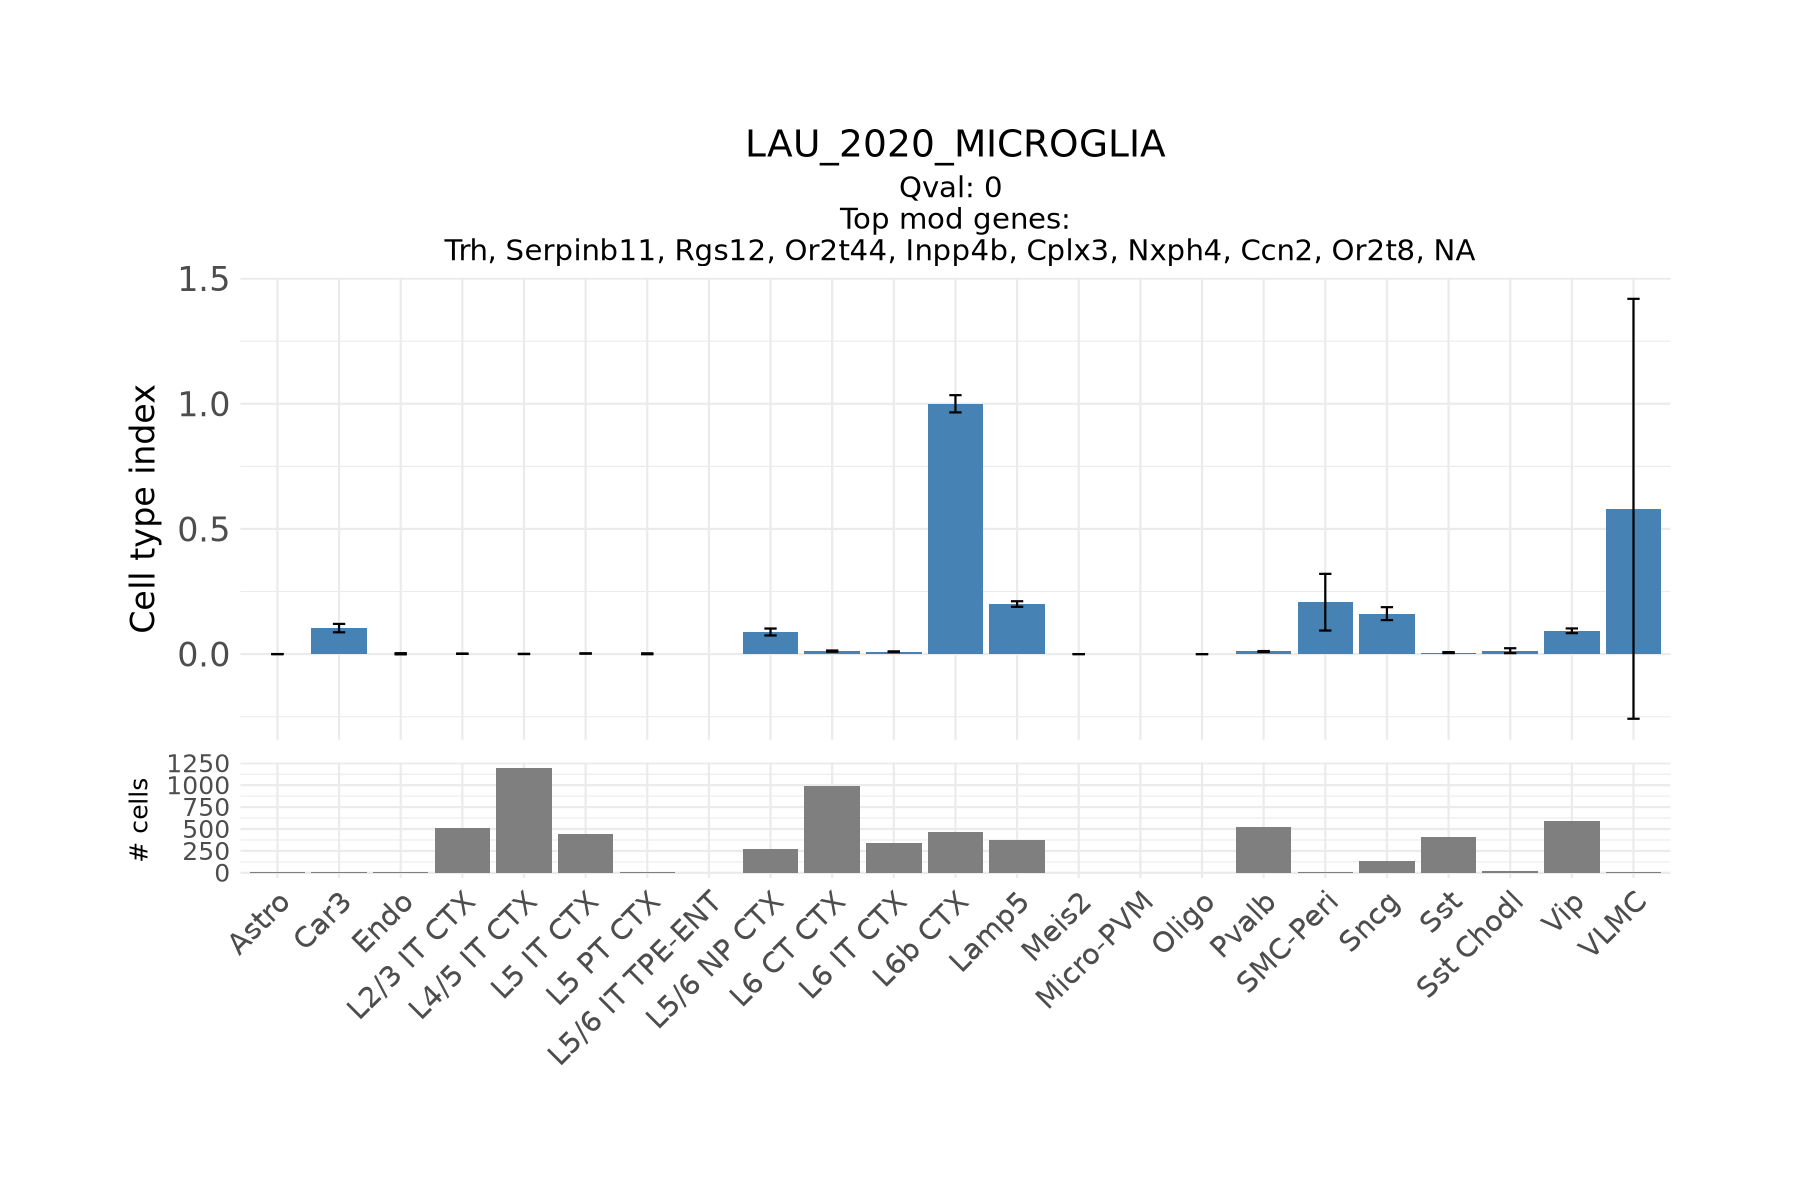

In [71]:
# for (i in 1:nrow(top_mods_df_subset)) {

    # i <- which(top_mods_df_subset$Cell_type == "LAU_2020_EXCIT")
    i <- which(names(marker_genes_list) == "L6b")

    # kME_path <- top_mods_df_subset$kME_path[i]
    # mod <- top_mods_df$Module[i]
    # mod_genes <- get_mod_genes(kME_path, mod, mod_def)
    # # Convert to mouse genes
    # mod_genes <- convert_genes(mod_genes, target_species="mouse")
    mod_genes <- convert_genes(marker_genes_list[[i]], target_species="mouse")

    ctype_index_list <- get_module_ctype_index(expr, mod_genes, sampleinfo$subclass_label)
    ctype_expr_index <- ctype_index_list[[1]]
    ctype_index_se <- ctype_index_list[[2]] 

    df <- data.frame(
        Cell_type=names(ctype_expr_index),
        Index=ctype_expr_index,
        SE=ctype_index_se,
        No.cells=as.numeric(table(sampleinfo$subclass_label))
    )

    plot_title <- top_mods_df_subset$Cell_type[i]
    plot_sub <- paste(
        "Qval:", round(top_mods_df_subset$Qval[i], 4), 
        "\nTop mod genes:\n", 
        paste(mod_genes[1:10], collapse=", ")
    )

    index_plot <- ggplot(data=df, aes(x=Cell_type, y=Index)) +
        geom_bar(stat="identity", fill="steelblue") +
        geom_errorbar(aes(ymin=Index-2*SE, ymax=Index+2*SE), width=0.2) +
        labs(y="Cell type index") +
        theme_minimal() +
        theme(
            plot.title=element_text(size=18, hjust=0.5),
            plot.subtitle=element_text(size=14, hjust=0.5),
            axis.title.x=element_blank(),
            axis.text.x=element_blank(),  # Remove labels from top
            axis.text.y=element_text(size=16),
            axis.title.y=element_text(size=16)
        ) +
        labs(title=plot_title, subtitle=plot_sub)

    n_cells_plot <- ggplot(data=df, aes(x=Cell_type, y=No.cells)) +
        geom_bar(stat="identity", fill="gray50") +
        labs(y="# cells") +
        theme_minimal() +
        theme(
            axis.title.x=element_blank(),
            axis.text.x=element_text(size=14, angle=45, hjust=1),
            axis.title.y=element_text(size=12),
            axis.text.y=element_text(size=12)
        ) 
        # scale_y_continuous(trans="log2")


    # Stack them
    print(index_plot / n_cells_plot + plot_layout(heights=c(4, 1)))

# }